# 04 — Rental Price Model Benchmark (V3)

Benchmarks leakage-safe regression models for the monthly asking rent and **locks one candidate before** a single, final evaluation on a sealed future TEST period.

| | |
|---|---|
| **Objective** | Choose a price model using development folds only, then measure it once on TEST. |
| **Input** | `data/silver/rental_listings.parquet` + the F1–F5 feature contract from Notebook 03 |
| **Output** | Benchmark tables and the champion artifact in `data/modeling/roombeacon_price_benchmark_v3/` (the persistence cell is skipped in the published run so the locked champion is not overwritten) |
| **Locked champion** | LightGBM / RAW target / F4 features — Notebooks 06 and 07 consume it |

**Contents**

- Setup
- 01. Runtime, canonical input and reproducibility
- 02. Business target, semantic population and leakage contract
- 03. Group-isolated chronological split
- 04. Fair preprocessing and model registry
- 05. F1–F5 development comparison and F4 vs F5 decision
- 06. Development-only RAW vs LOG1P comparison
- 07. Small bounded tuning and candidate lock
- 08. Source ablation and leave-one-source-out (development only)
- 09. UNKNOWN sensitivity — PERMISSIVE vs STRICT (development only)
- 10. FINAL TEST — ONE-TIME EVALUATION
- 11. Tail, segment, prediction-sanity and largest-error diagnostics
- 12. Locked-model feature importance and final verdict
- 13. Consistency with the locked champion (read-only)
- 14. Persist auditable benchmark evidence
- Summary

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB04 current
```

The highlighted step is this notebook.

## Evaluation protocol

```mermaid
flowchart LR
    S[("Eligible Silver rows")] --> G["Group duplicates<br/>(no group in two splits)"]
    G --> T["Order groups by time"]
    T --> D["DEVELOPMENT<br/>train + validation"]
    T --> X[("TEST<br/>sealed")]
    D --> F["3 expanding time folds"]
    F --> C["Compare features, models,<br/>RAW vs LOG1P, small tuning"]
    C --> L["Lock ONE candidate<br/>(within 1% → simpler model)"]
    L --> E["Retrain on DEVELOPMENT<br/>evaluate ONCE on TEST"]
    X --> E
```

`TEST_ACCESSED_FOR_SELECTION` is asserted `False` at every selection step; TEST rows are first touched in
section 10.

## Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

import json
import os
import platform
import time
from datetime import datetime, timezone

import catboost
import duckdb
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from catboost import CatBoostRegressor
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.listing_semantics import BUSINESS_TARGET_DEFINITION
from notebooks.utils.modeling_benchmark import *  # noqa: F403 — benchmark helpers and TARGET
from notebooks.utils.modeling_benchmark import prepare_lightgbm_categories
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    NEUTRAL,
    apply_style,
    bar_chart,
    funnel_chart,
    histogram,
)
from notebooks.utils.shadow_validation import (
    build_reference_profile,
    file_sha256,
    persist_champion_artifact,
)

SEED = 42
np.random.seed(SEED)
apply_style()

## 01. Runtime, canonical input and reproducibility

> **Why:** Pin the exact Silver input and library versions so every number can be reproduced.

In [2]:
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.parquet"
METADATA_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.metadata.json"
with duckdb.connect(":memory:") as con:
    silver_df = con.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()
silver_metadata = json.loads(METADATA_PATH.read_text())
assert len(silver_df) == silver_df.rental_post_id.nunique() == silver_metadata["row_count"]

versions = {
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "lightgbm": lightgbm.__version__,
    "catboost": catboost.__version__,
}
display(
    pd.Series(
        {
            "Silver rows": f"{len(silver_df):,}",
            "Silver snapshot": silver_metadata["source_snapshot"]["snapshot_id"],
            **versions,
        },
        name="value",
    ).to_frame()
)

,value
Silver rows,"132,494"
Silver snapshot,db804eae-1774-4659-aa9a-255830997f5d
Python,3.12.3
pandas,3.0.6
numpy,2.5.3
scikit-learn,1.9.1
xgboost,3.0.5
lightgbm,4.7.0
catboost,1.2.8


## 02. Business target, semantic population and leakage contract

> **Why:** Model only rows whose price is a trusted monthly rent for an ordinary unit, and audit every exclusion.

**Business target:** the asking monthly rent of an ordinary individual rental unit.
SALE, TRANSFER, WHOLE_BUILDING and MULTI_UNIT_BUSINESS evidence is incompatible. `UNKNOWN` is kept when
nothing conflicts (PERMISSIVE); STRICT is evaluated separately in section 09. Semantic labels decide
eligibility only — they are never predictors.

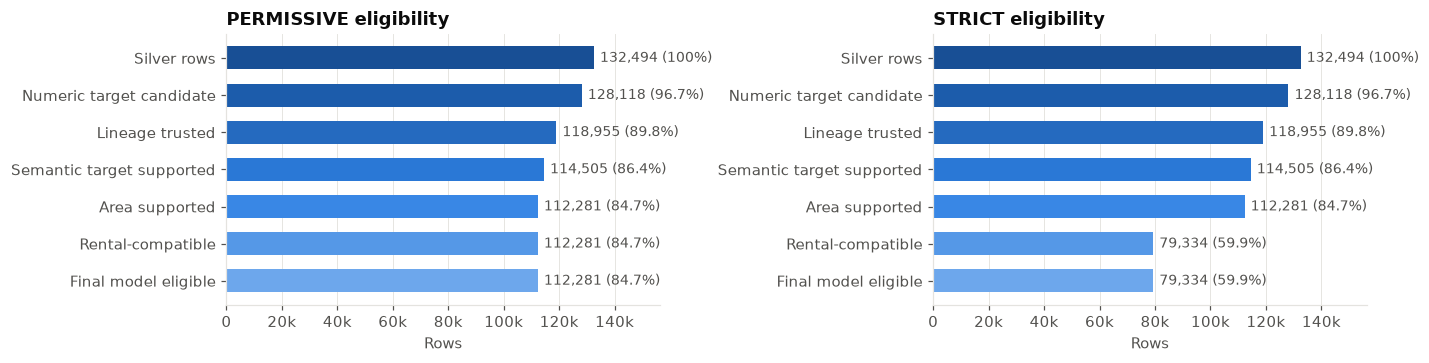

In [3]:
prepared = engineer_safe_features(silver_df)
TRUSTED_PRICE_STATUSES = {"TRUSTED_EXISTING", "TRUSTED_REPARSED"}
permissive_masks = build_modeling_eligibility(prepared, policy="PERMISSIVE")
strict_masks = build_modeling_eligibility(prepared, policy="STRICT")
eligibility_funnel_permissive = eligibility_funnel(permissive_masks)
eligibility_funnel_strict = eligibility_funnel(strict_masks)

numeric_candidate = permissive_masks.numeric_target_candidate
numeric_trusted = permissive_masks.lineage_trusted
semantic_compatible = permissive_masks.rental_compatible
prepared["semantic_eligibility_reason"] = pd.Series(
    np.where(semantic_compatible, "SEMANTICALLY_COMPATIBLE", "NOT_RENTAL_COMPATIBLE"),
    index=prepared.index,
    dtype="string",
)
eligible = permissive_masks.final_eligible
model_df = prepared.loc[eligible].copy()
model_df[TARGET] = model_df.price_model_value.astype(float)
model_df["group_key"] = build_group_key(model_df)

FEATURE_SETS = build_feature_sets(model_df.columns)
for features in FEATURE_SETS.values():
    audit_features(features)

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 3.4))
funnel_chart(
    eligibility_funnel_permissive.set_index("Stage")["Rows"],
    title="PERMISSIVE eligibility",
    ax=left,
)
funnel_chart(
    eligibility_funnel_strict.set_index("Stage")["Rows"], title="STRICT eligibility", ax=right
)
plt.tight_layout()
plt.show()

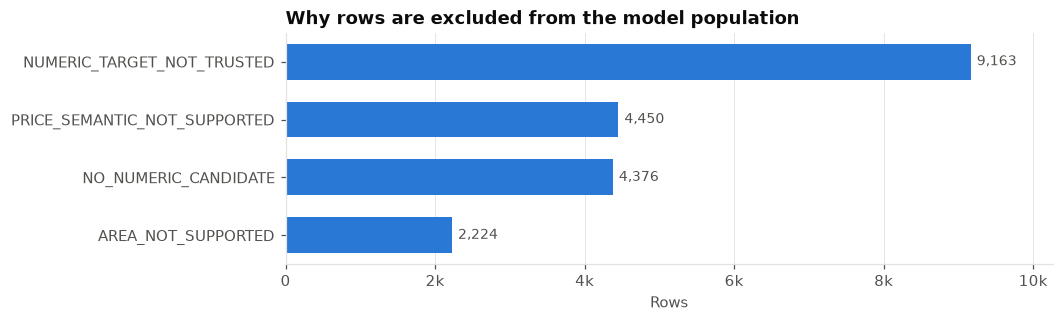

,model_exclusion_reason,price_target_trust_status,listing_intent,rental_scope,source_code,Rows
25,MODEL_ELIGIBLE,TRUSTED_EXISTING,RENT,SINGLE_OR_ORDINARY_UNIT,phongtro123,46219
31,MODEL_ELIGIBLE,TRUSTED_EXISTING,UNKNOWN,UNKNOWN,phongtro123,22185
22,MODEL_ELIGIBLE,TRUSTED_EXISTING,RENT,SINGLE_OR_ORDINARY_UNIT,chothuephongtro,20258
21,MODEL_ELIGIBLE,TRUSTED_EXISTING,RENT,SINGLE_OR_ORDINARY_UNIT,cafeland,9287
27,MODEL_ELIGIBLE,TRUSTED_EXISTING,UNKNOWN,UNKNOWN,chothuephongtro,5656
73,NUMERIC_TARGET_NOT_TRUSTED,PARSER_DISAGREEMENT_REVIEW,RENT,SINGLE_OR_ORDINARY_UNIT,mogi,4037
80,NUMERIC_TARGET_NOT_TRUSTED,PARSER_DISAGREEMENT_REVIEW,UNKNOWN,UNKNOWN,mogi,2638
44,NO_NUMERIC_CANDIDATE,MISSING,RENT,SINGLE_OR_ORDINARY_UNIT,chothuephongtro,2580
29,MODEL_ELIGIBLE,TRUSTED_EXISTING,UNKNOWN,UNKNOWN,nhatot,2381
104,PRICE_SEMANTIC_NOT_SUPPORTED,TRUSTED_EXISTING,RENT,SINGLE_OR_ORDINARY_UNIT,chothuephongtro,1959


In [4]:
prepared["model_exclusion_reason"] = np.select(
    [
        ~numeric_candidate,
        numeric_candidate & ~numeric_trusted,
        numeric_trusted & ~permissive_masks.semantic_target_supported,
        permissive_masks.semantic_target_supported & ~permissive_masks.area_supported,
        permissive_masks.area_supported & ~permissive_masks.rental_compatible,
    ],
    [
        "NO_NUMERIC_CANDIDATE",
        "NUMERIC_TARGET_NOT_TRUSTED",
        "PRICE_SEMANTIC_NOT_SUPPORTED",
        "AREA_NOT_SUPPORTED",
        "NOT_RENTAL_COMPATIBLE",
    ],
    default="MODEL_ELIGIBLE",
)
semantic_population_summary = eligibility_funnel_permissive.rename(columns={"Stage": "Population"})
semantic_exclusion_summary = (
    prepared.groupby(
        [
            "model_exclusion_reason",
            "price_target_trust_status",
            "listing_intent",
            "rental_scope",
            "source_code",
        ],
        dropna=False,
    )
    .size()
    .rename("Rows")
    .reset_index()
    .sort_values("Rows", ascending=False)
)
bar_chart(
    prepared.model_exclusion_reason.value_counts().drop("MODEL_ELIGIBLE", errors="ignore"),
    title="Why rows are excluded from the model population",
    xlabel="Rows",
)
plt.show()
display(semantic_exclusion_summary.head(15))

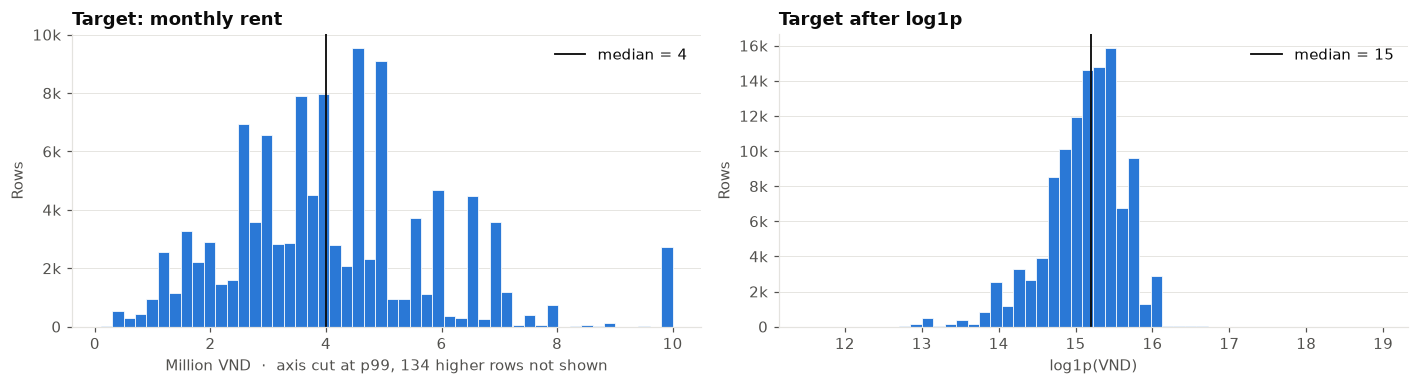

,Population,Rows,Min,P01,P05,P25,Median,P75,P95,P99,Max
0,Before numeric-trust filtering,128118,13000.0,800000.0,1300000.0,3000000.0,4000000.0,5000000.0,10000000.0,10000000.0,2.750000e+11
1,Final eligible trusted target,112281,100000.0,800000.0,1400000.0,2900000.0,4000000.0,5000000.0,7000000.0,10000000.0,1.700000e+08


**Valid high-price rows kept by canonical trust evidence** (not removed as outliers):

,rental_post_id,source_code,title_clean,price_model_value,area_value_clean,listing_intent,rental_scope
114907,255337,nhatot,Mô tả chi tiết,170000000.0,189.0,UNKNOWN,UNKNOWN
9692,68016,mogi,"Cho thuê gấp Panorama, Phú Mỹ Hưng, Quận 7",60000000.0,142.0,RENT,SINGLE_OR_ORDINARY_UNIT
113333,251674,phongtro123,"SANG HĐ NHÀ CHO THUÊ 13 CĂN HỘ ĐẶNG VĂN NGỮ, P...",50000000.0,400.0,RENT,SINGLE_OR_ORDINARY_UNIT
11945,70708,mogi,"Cần cho thuê nguyên căn nhà phố Hưng Gia, Hưng...",45000000.0,111.0,RENT,SINGLE_OR_ORDINARY_UNIT
11947,70710,mogi,"Cần cho thuê nguyên căn nhà phố Hưng Gia, Hưng...",43000000.0,111.0,RENT,SINGLE_OR_ORDINARY_UNIT
47348,114400,phongtro123,"CHO THUE NHA CAP 4 GAN DAI HOC NGAN HANG, CAO ...",35000000.0,40.0,RENT,SINGLE_OR_ORDINARY_UNIT
17837,77546,cafeland,Phòng trọ: CHO THUÊ NHÀ ( 5x20m) 30triệu Đường...,30000000.0,100.0,RENT,SINGLE_OR_ORDINARY_UNIT
74862,178308,phongtro123,"Cho thuê Hoàng Anh River View full NT 4PN 4WC,...",30000000.0,177.0,RENT,SINGLE_OR_ORDINARY_UNIT


In [5]:
def distribution_row(name, values):
    quantiles = values.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    return {
        "Population": name,
        "Rows": len(values),
        "Min": values.min(),
        **dict(zip(["P01", "P05", "P25", "Median", "P75", "P95", "P99"], quantiles.values)),
        "Max": values.max(),
    }


before = prepared.loc[numeric_candidate, "price_amount_clean"].astype(float)
target = model_df[TARGET].astype(float)
target_distribution_comparison = pd.DataFrame(
    [
        distribution_row("Before numeric-trust filtering", before),
        distribution_row("Final eligible trusted target", target),
    ]
)
semantic_exclusion_examples = (
    prepared.loc[
        prepared.model_exclusion_reason.ne("MODEL_ELIGIBLE"),
        [
            "rental_post_id",
            "source_code",
            "title_clean",
            "price_amount_clean",
            "price_model_value",
            "price_target_model_value",
            "price_target_trust_status",
            "price_target_trust_reason",
            "listing_intent",
            "rental_scope",
            "model_exclusion_reason",
        ],
    ]
    .groupby("model_exclusion_reason", group_keys=False)
    .head(8)
)
valid_high_price_examples = prepared.loc[
    eligible,
    [
        "rental_post_id",
        "source_code",
        "title_clean",
        TARGET,
        "area_value_clean",
        "listing_intent",
        "rental_scope",
    ],
].nlargest(20, TARGET)

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 3.6))
histogram(target / 1e6, title="Target: monthly rent", xlabel="Million VND", ax=left)
histogram(
    np.log1p(target), title="Target after log1p", xlabel="log1p(VND)", clip_quantile=None, ax=right
)
plt.tight_layout()
plt.show()
display(target_distribution_comparison)
display(
    Markdown(
        "**Valid high-price rows kept by canonical trust evidence** (not removed as outliers):"
    )
)
display(valid_high_price_examples.head(8))

In [6]:
display(
    pd.DataFrame([{"Feature set": k, "Features": ", ".join(v)} for k, v in FEATURE_SETS.items()])
)
display(
    Markdown(
        "**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, "
        "parser/quality fields and every target-reconstructive field."
    )
)

,Feature set,Features
0,F1 — AREA ONLY,area_value_clean
1,F2 — AREA + SOURCE,"area_value_clean, source_code"
2,F3 — AREA + LOCATION,"area_value_clean, ward_current, district_text_..."
3,F4 — AREA + SOURCE + LOCATION,"area_value_clean, source_code, ward_current, d..."
4,F5 — FULL SAFE TABULAR,"area_value_clean, source_code, ward_current, d..."


**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, parser/quality fields and every target-reconstructive field.

## 03. Group-isolated chronological split

> **Why:** Keep reposts of the same listing in one split and test on the most recent period.

In [7]:
split_result = group_aware_split(model_df, model_df.group_key, seed=SEED)
model_df["split"] = split_result.labels
assert_group_isolation(model_df.group_key, model_df.split)
assert_split_chronology(model_df, model_df.group_key, split_result)

development_df = model_df.loc[model_df.split.ne("TEST")].copy()
test_df = model_df.loc[model_df.split.eq("TEST")].copy()
folds = build_expanding_group_time_folds(development_df, development_df.group_key, n_splits=3)

split_report = (
    model_df.groupby("split")
    .agg(
        Rows=("rental_post_id", "size"),
        Groups=("group_key", "nunique"),
        Target_Median=(TARGET, "median"),
        Target_P95=(TARGET, lambda x: x.quantile(0.95)),
        Target_Max=(TARGET, "max"),
        Min_Time=("latest_observed_at", "min"),
        Max_Time=("latest_observed_at", "max"),
    )
    .reindex(["TRAIN", "VALIDATION", "TEST"])
)
fold_report = pd.DataFrame(
    [
        {
            "Fold": f.fold,
            "Train Rows": len(f.train_index),
            "Validation Rows": len(f.validation_index),
            "Train Groups": f.train_groups,
            "Validation Groups": f.validation_groups,
            "Train Start": f.train_start,
            "Train End": f.train_end,
            "Validation Start": f.validation_start,
            "Validation End": f.validation_end,
        }
        for f in folds
    ]
)
TEST_ACCESSED_FOR_SELECTION = False

Each bar is the time window of a split or fold. Folds expand forward in time and never see TEST.

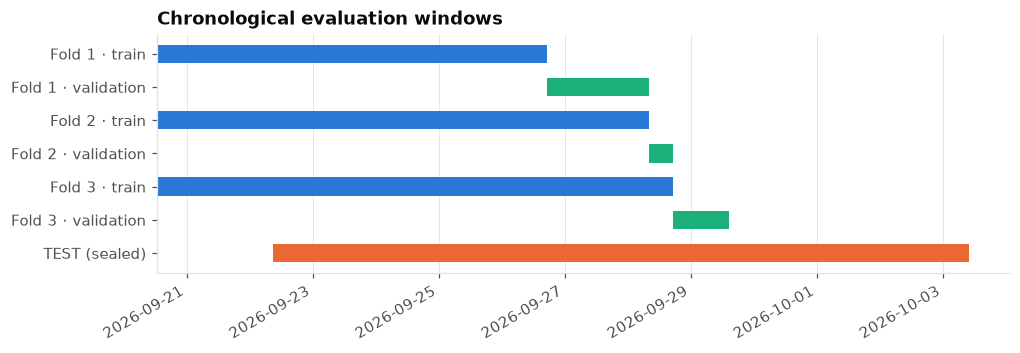

,value
Strategy,GROUP_LEVEL_CHRONOLOGICAL_70_15_15
Reason,Whole duplicate groups ordered by representati...
Limitation,"Short window: future evidence over days, not l..."


,Rows,Groups,Target_Median,Target_P95,Target_Max,Min_Time,Max_Time
split,,,,,,,
TRAIN,77557,76795,4000000.0,7200000.0,170000000.0,2026-09-20 12:48:44,2026-09-28 15:33:33
VALIDATION,18220,16456,3900000.0,6500000.0,60000000.0,2026-09-22 08:11:39,2026-09-29 14:31:04
TEST,16504,16457,3600000.0,6000000.0,35000000.0,2026-09-22 09:01:22,2026-10-03 09:57:20


In [8]:
timeline = [
    (
        "TEST (sealed)",
        split_report.loc["TEST", "Min_Time"],
        split_report.loc["TEST", "Max_Time"],
        CATEGORICAL[1],
    )
]
for f in reversed(folds):
    timeline.append(
        (f"Fold {f.fold} · validation", f.validation_start, f.validation_end, CATEGORICAL[2])
    )
    timeline.append((f"Fold {f.fold} · train", f.train_start, f.train_end, CATEGORICAL[0]))
fig, ax = plt.subplots(figsize=(10, 3.2))
for y, (label, start, end, color) in enumerate(timeline):
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    ax.barh(y, (end - start) / pd.Timedelta(days=1), left=start, color=color, height=0.55)
ax.set_yticks(range(len(timeline)), [row[0] for row in timeline])
ax.set_title("Chronological evaluation windows")
fig.autofmt_xdate()
plt.show()
display(
    pd.Series(
        {
            "Strategy": split_result.strategy,
            "Reason": split_result.reason,
            "Limitation": "Short window: future evidence over days, not long-term generalization",
        },
        name="value",
    ).to_frame()
)
display(split_report)

## 04. Fair preprocessing and model registry

> **Why:** Give every model the same leakage-safe preprocessing, learned inside each fold.

Sklearn models get fold-fitted one-hot encoding (unknown-category safe); CatBoost uses native strings; LightGBM uses train-defined pandas categories. Target transforms and imputers are learned per fold.

In [9]:
CATS = ["source_code", "ward_current", "district_text_extracted", "province_text_extracted"]
BASELINES = ["Global Median", "Hierarchical Location Median", "Hierarchical Segment Median"]
MODEL_ORDER = [
    "Linear Regression",
    "Ridge Regression",
    "ElasticNet",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Extra Trees Regressor",
    "Gradient Boosting Regressor",
    "HistGradientBoosting Regressor",
    "XGBoost Regressor",
    "LightGBM Regressor",
    "CatBoost Regressor",
]
BASE_PARAMS = {
    "Linear Regression": {},
    "Ridge Regression": {"alpha": 100.0},
    "ElasticNet": {"alpha": 0.001, "l1_ratio": 0.5},
    "Decision Tree Regressor": {"max_depth": 12, "min_samples_leaf": 30},
    "Random Forest Regressor": {
        "n_estimators": 80,
        "max_depth": 16,
        "min_samples_leaf": 5,
        "max_features": 0.8,
    },
    "Extra Trees Regressor": {
        "n_estimators": 80,
        "max_depth": 16,
        "min_samples_leaf": 5,
        "max_features": 0.8,
    },
    "Gradient Boosting Regressor": {
        "n_estimators": 80,
        "learning_rate": 0.05,
        "max_depth": 3,
        "loss": "huber",
    },
    "HistGradientBoosting Regressor": {
        "max_iter": 100,
        "learning_rate": 0.07,
        "max_leaf_nodes": 31,
        "loss": "absolute_error",
    },
    "XGBoost Regressor": {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "objective": "reg:absoluteerror",
    },
    "LightGBM Regressor": {
        "n_estimators": 120,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 30,
        "objective": "mae",
    },
    "CatBoost Regressor": {
        "iterations": 140,
        "depth": 7,
        "learning_rate": 0.06,
        "l2_leaf_reg": 5,
        "loss_function": "MAE",
    },
}
SKLEARN_MODELS = {
    "Linear Regression": lambda p: LinearRegression(**p),
    "Ridge Regression": lambda p: Ridge(**p),
    "ElasticNet": lambda p: ElasticNet(max_iter=3000, random_state=SEED, **p),
    "Decision Tree Regressor": lambda p: DecisionTreeRegressor(random_state=SEED, **p),
    "Random Forest Regressor": lambda p: RandomForestRegressor(n_jobs=-1, random_state=SEED, **p),
    "Extra Trees Regressor": lambda p: ExtraTreesRegressor(n_jobs=-1, random_state=SEED, **p),
    "Gradient Boosting Regressor": lambda p: GradientBoostingRegressor(random_state=SEED, **p),
    "HistGradientBoosting Regressor": lambda p: HistGradientBoostingRegressor(
        random_state=SEED, **p
    ),
    "XGBoost Regressor": lambda p: XGBRegressor(n_jobs=-1, random_state=SEED, **p),
}


def frames(frame, features, native=False):
    out = frame[features].copy()
    for column in set(features) & set(CATS):
        if native:
            out[column] = out[column].astype("string").fillna("__MISSING__")
        else:
            out[column] = out[column].astype("object").where(out[column].notna(), np.nan)
    return out


def sklearn_pipeline(name, params, features):
    numeric = [c for c in features if c not in CATS]
    categorical = [c for c in features if c in CATS]
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if name in ["Linear Regression", "Ridge Regression", "ElasticNet"]:
        numeric_steps.append(("scale", StandardScaler()))
    if name == "HistGradientBoosting Regressor":
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    else:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    preprocessor = ColumnTransformer(
        [
            ("num", Pipeline(numeric_steps), numeric),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                        ("encoder", encoder),
                    ]
                ),
                categorical,
            ),
        ],
        sparse_threshold=1.0,
    )
    if name not in SKLEARN_MODELS:
        raise ValueError(name)
    return Pipeline([("preprocessor", preprocessor), ("model", SKLEARN_MODELS[name](params))])


def fit_predict(name, params, features, fit, score, transform):
    y = transform_target(fit[TARGET], transform)
    started = time.perf_counter()
    if name == "CatBoost Regressor":
        model = CatBoostRegressor(
            random_seed=SEED, verbose=False, allow_writing_files=False, thread_count=-1, **params
        )
        model.fit(frames(fit, features, True), y, cat_features=[c for c in features if c in CATS])
        fit_seconds = time.perf_counter() - started
        predict_started = time.perf_counter()
        pred = model.predict(frames(score, features, True))
    elif name == "LightGBM Regressor":
        categorical = [c for c in features if c in CATS]
        X, Z = prepare_lightgbm_categories(fit[features], score[features], categorical)
        model = LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1, **params)
        model.fit(X, y, categorical_feature=categorical)
        fit_seconds = time.perf_counter() - started
        predict_started = time.perf_counter()
        pred = model.predict(Z)
    else:
        model = sklearn_pipeline(name, params, features)
        model.fit(frames(fit, features), y)
        fit_seconds = time.perf_counter() - started
        predict_started = time.perf_counter()
        pred = model.predict(frames(score, features))
    return (
        model,
        inverse_target(pred, transform),
        fit_seconds,
        time.perf_counter() - predict_started,
    )


def baseline_predict(name, fit, score):
    if name == "Global Median":
        return np.full(len(score), float(fit[TARGET].median()))
    if name == "Hierarchical Location Median":
        return hierarchical_location_median(fit, score)
    return hierarchical_segment_median(fit, score)


def evaluate_config(name, params, features, feature_set, transform):
    rows = []
    for f in folds:
        fit = development_df.loc[f.train_index]
        score = development_df.loc[f.validation_index]
        if name in BASELINES:
            started = time.perf_counter()
            pred = baseline_predict(name, fit, score)
            fit_seconds, predict_seconds = 0.0, time.perf_counter() - started
        else:
            _, pred, fit_seconds, predict_seconds = fit_predict(
                name, params, features, fit, score, transform
            )
        rows.append(
            {
                "Fold": f.fold,
                "Model": name,
                "Target Transform": transform,
                "Feature Set": feature_set,
                "Parameters": json.dumps(params, sort_keys=True),
                **regression_metrics(score[TARGET], pred),
                "Fit Time": fit_seconds,
                "Prediction Time": predict_seconds,
                "Train Rows": len(fit),
                "Validation Rows": len(score),
                "Train Groups": f.train_groups,
                "Validation Groups": f.validation_groups,
                "Group Overlap": 0,
                "Train Start": f.train_start,
                "Train End": f.train_end,
                "Validation Start": f.validation_start,
                "Validation End": f.validation_end,
                "Target Median": score[TARGET].median(),
                "Target P95": score[TARGET].quantile(0.95),
                "Target Max": score[TARGET].max(),
            }
        )
    return rows

## 05. F1–F5 development comparison and F4 vs F5 decision

> **Why:** Decide which feature set to use; F5 must beat F4 consistently and by ≥ 1% to justify extra features.

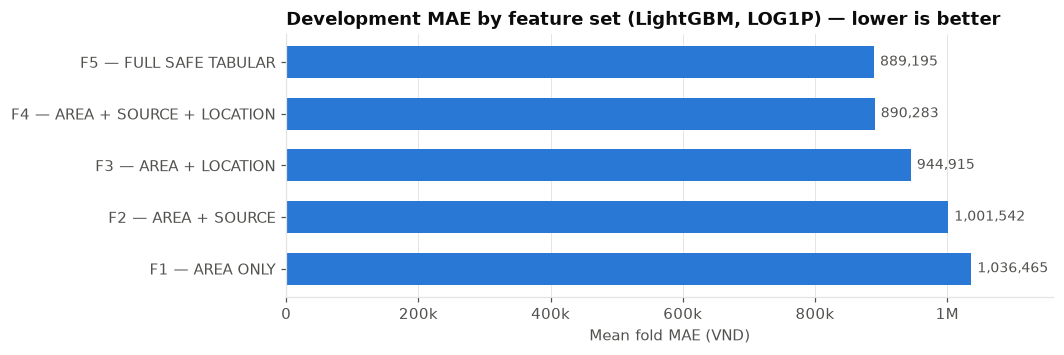

,Model,Target Transform,F4 MAE,F5 MAE,F5 absolute improvement,F5 improvement %,F5 better
0,CatBoost Regressor,LOG1P,924285.511939,904682.009557,19603.502381,2.120936,True
1,LightGBM Regressor,LOG1P,890282.600087,889194.590374,1088.009714,0.122209,True
2,LightGBM Regressor,RAW,890978.697365,889578.796821,1399.900543,0.157119,True


,value
F5 consistently better,True
Aggregate F5 improvement %,0.82
Decision,F4 — AREA + SOURCE + LOCATION


In [10]:
F4, F5 = "F4 — AREA + SOURCE + LOCATION", "F5 — FULL SAFE TABULAR"
feature_rows = []
for feature_set, features in FEATURE_SETS.items():
    feature_rows += evaluate_config(
        "LightGBM Regressor", BASE_PARAMS["LightGBM Regressor"], features, feature_set, "LOG1P"
    )
for feature_set in [F4, F5]:
    feature_rows += evaluate_config(
        "CatBoost Regressor",
        BASE_PARAMS["CatBoost Regressor"],
        FEATURE_SETS[feature_set],
        feature_set,
        "LOG1P",
    )
    feature_rows += evaluate_config(
        "LightGBM Regressor",
        BASE_PARAMS["LightGBM Regressor"],
        FEATURE_SETS[feature_set],
        feature_set,
        "RAW",
    )
feature_fold_results = pd.DataFrame(feature_rows)
feature_summary = summarize_development(feature_fold_results)

lgbm_log = feature_summary.loc[
    feature_summary.Model.eq("LightGBM Regressor") & feature_summary["Target Transform"].eq("LOG1P")
]
bar_chart(
    lgbm_log.set_index("Feature Set")["MAE_Mean"],
    title="Development MAE by feature set (LightGBM, LOG1P) — lower is better",
    xlabel="Mean fold MAE (VND)",
    sort=False,
)
plt.show()

f45 = feature_summary.loc[feature_summary["Feature Set"].isin([F4, F5])].copy()
f45_rows = []
for (model, transform), group in f45.groupby(["Model", "Target Transform"]):
    f4 = group.loc[group["Feature Set"].str.startswith("F4")].iloc[0]
    f5 = group.loc[group["Feature Set"].str.startswith("F5")].iloc[0]
    f45_rows.append(
        {
            "Model": model,
            "Target Transform": transform,
            "F4 MAE": f4.MAE_Mean,
            "F5 MAE": f5.MAE_Mean,
            "F5 absolute improvement": f4.MAE_Mean - f5.MAE_Mean,
            "F5 improvement %": (f4.MAE_Mean - f5.MAE_Mean) / f4.MAE_Mean * 100,
            "F5 better": f5.MAE_Mean < f4.MAE_Mean,
        }
    )
f45_decision = pd.DataFrame(f45_rows)
consistent = bool(f45_decision["F5 better"].all())
aggregate_gain = f45_decision["F5 absolute improvement"].sum() / f45_decision["F4 MAE"].sum() * 100
SELECTED_FEATURE_SET = F5 if consistent and aggregate_gain >= 1.0 else F4
SELECTED_FEATURES = FEATURE_SETS[SELECTED_FEATURE_SET]
display(f45_decision)
display(
    pd.Series(
        {
            "F5 consistently better": consistent,
            "Aggregate F5 improvement %": round(aggregate_gain, 2),
            "Decision": SELECTED_FEATURE_SET,
        },
        name="value",
    ).to_frame()
)

## 06. Development-only RAW vs LOG1P comparison

> **Why:** Compare 11 model families and 3 train-only baselines, each with a RAW and a LOG1P target.

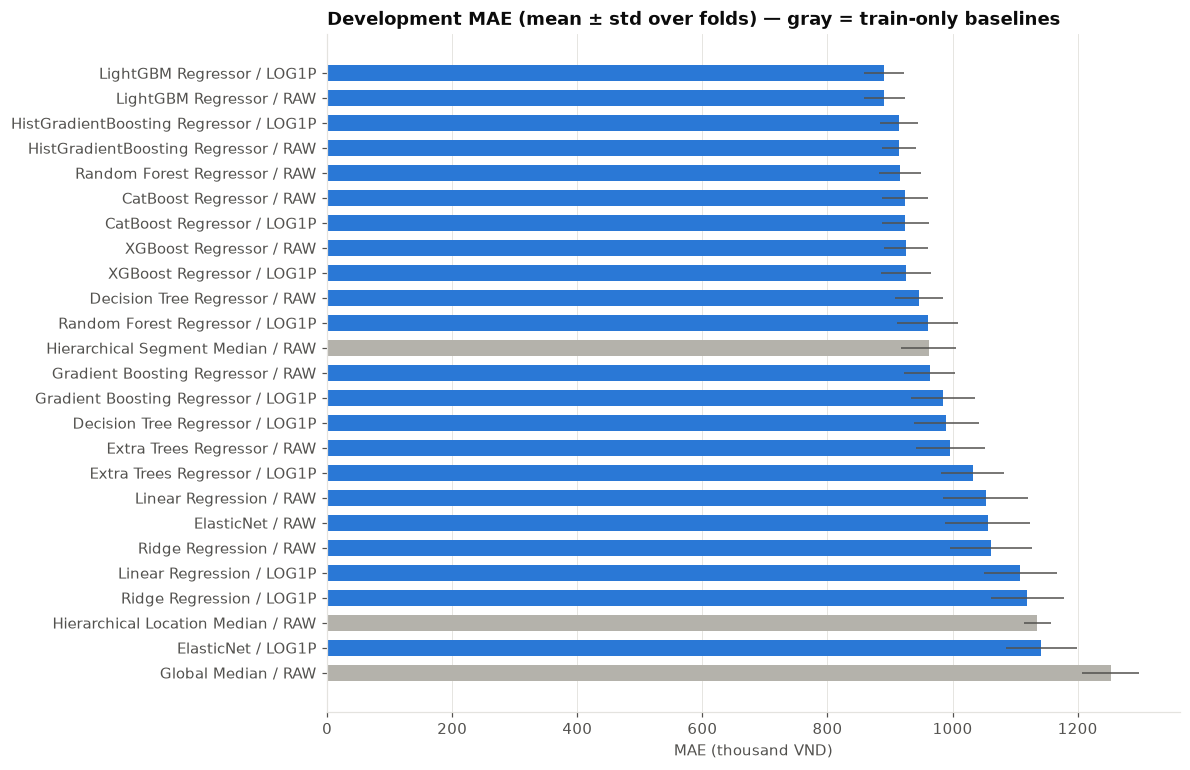

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
15,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.902826e+05,8.773849e+05,32010.080465,6.368376e+05,0.374194,0.617995
16,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.909787e+05,8.758011e+05,32608.474011,6.434994e+05,0.374988,0.548733
13,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,9.144741e+05,9.052818e+05,30072.643915,6.652799e+05,0.378436,0.425783
14,HistGradientBoosting Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,9.147849e+05,9.029004e+05,27288.056739,6.721803e+05,0.378280,0.415811
20,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,9.160145e+05,8.967642e+05,33625.452589,6.645658e+05,0.379307,2.047689
1,CatBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.242497e+05,9.366218e+05,36665.622692,6.810430e+05,0.380682,1.160589
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.242855e+05,9.355007e+05,37839.046596,6.795056e+05,0.380186,1.129179
24,XGBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,9.255684e+05,9.133556e+05,35225.738696,6.777665e+05,0.378537,2.098185
23,XGBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,9.255771e+05,9.102669e+05,39328.304507,6.765411e+05,0.378432,1.300472
3,Decision Tree Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 12, ""min_samples_leaf"": 30}",3,9.457502e+05,9.244832e+05,38563.721613,6.939090e+05,0.387434,0.176151


In [11]:
development_rows = []
for baseline in BASELINES:
    development_rows += evaluate_config(
        baseline, {}, SELECTED_FEATURES, "TRAIN-ONLY BASELINE", "RAW"
    )
for name in MODEL_ORDER:
    for transform in ["RAW", "LOG1P"]:
        development_rows += evaluate_config(
            name, BASE_PARAMS[name], SELECTED_FEATURES, SELECTED_FEATURE_SET, transform
        )
development_fold_results = pd.DataFrame(development_rows)
development_comparison = summarize_development(development_fold_results)
assert not TEST_ACCESSED_FOR_SELECTION

plot = development_comparison.sort_values("MAE_Mean")
labels = plot.Model + " / " + plot["Target Transform"]
colors = [NEUTRAL if model in BASELINES else CATEGORICAL[0] for model in plot.Model]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    labels,
    plot.MAE_Mean / 1e3,
    xerr=plot.MAE_Std / 1e3,
    color=colors,
    height=0.65,
    error_kw={"ecolor": "#52514e", "elinewidth": 1},
)
ax.invert_yaxis()
ax.set(
    title="Development MAE (mean ± std over folds) — gray = train-only baselines",
    xlabel="MAE (thousand VND)",
)
plt.show()
display(development_comparison)

## 07. Small bounded tuning and candidate lock

> **Why:** Refine only the top three families slightly, then lock one candidate before TEST is opened.

Selection rule: lowest development MAE; within 1% prefer the simpler model; then MedianAE, RMSLE, runtime.

In [12]:
best_family = development_comparison.sort_values("MAE_Mean").drop_duplicates("Model")
ml_shortlist = best_family.loc[~best_family.Model.isin(BASELINES)].head(3)
TUNING = {
    "CatBoost Regressor": [
        BASE_PARAMS["CatBoost Regressor"],
        {**BASE_PARAMS["CatBoost Regressor"], "depth": 6, "iterations": 200},
    ],
    "LightGBM Regressor": [
        BASE_PARAMS["LightGBM Regressor"],
        {**BASE_PARAMS["LightGBM Regressor"], "num_leaves": 63, "n_estimators": 180},
    ],
    "XGBoost Regressor": [
        BASE_PARAMS["XGBoost Regressor"],
        {**BASE_PARAMS["XGBoost Regressor"], "max_depth": 5, "n_estimators": 160},
    ],
    "HistGradientBoosting Regressor": [
        BASE_PARAMS["HistGradientBoosting Regressor"],
        {**BASE_PARAMS["HistGradientBoosting Regressor"], "max_iter": 160, "max_leaf_nodes": 63},
    ],
    "Random Forest Regressor": [
        BASE_PARAMS["Random Forest Regressor"],
        {**BASE_PARAMS["Random Forest Regressor"], "n_estimators": 140},
    ],
    "Extra Trees Regressor": [
        BASE_PARAMS["Extra Trees Regressor"],
        {**BASE_PARAMS["Extra Trees Regressor"], "n_estimators": 140},
    ],
}
tuning_rows = []
for _, row in ml_shortlist.iterrows():
    transform = "RAW" if row["Model"] == "LightGBM Regressor" else row["Target Transform"]
    for params in TUNING.get(row["Model"], [BASE_PARAMS[row["Model"]]]):
        tuning_rows += evaluate_config(
            row["Model"], params, SELECTED_FEATURES, SELECTED_FEATURE_SET, transform
        )
tuning_fold_results = pd.DataFrame(tuning_rows)
tuning_summary = summarize_development(tuning_fold_results)

candidate_pool = pd.concat(
    [
        development_comparison.loc[development_comparison.Model.str.contains("Median")],
        tuning_summary,
    ],
    ignore_index=True,
)
COMPLEXITY = {
    name: rank
    for rank, name in enumerate(
        BASELINES
        + [
            "Linear Regression",
            "Ridge Regression",
            "ElasticNet",
            "Decision Tree Regressor",
            "HistGradientBoosting Regressor",
            "Gradient Boosting Regressor",
            "Random Forest Regressor",
            "Extra Trees Regressor",
            "LightGBM Regressor",
            "XGBoost Regressor",
            "CatBoost Regressor",
        ]
    )
}
LOCKED_CANDIDATE = lock_candidate(candidate_pool, COMPLEXITY, tolerance=0.01)
LOCKED_MODEL = LOCKED_CANDIDATE.Model
LOCKED_TRANSFORM = LOCKED_CANDIDATE["Target Transform"]
LOCKED_PARAMS = json.loads(LOCKED_CANDIDATE.Parameters)
assert not TEST_ACCESSED_FOR_SELECTION

locked_fold_report = tuning_fold_results.loc[
    tuning_fold_results.Model.eq(LOCKED_MODEL)
    & tuning_fold_results.Parameters.eq(json.dumps(LOCKED_PARAMS, sort_keys=True))
].sort_values("Fold")
assert locked_fold_report["Group Overlap"].eq(0).all()
display(tuning_summary)
display(
    Markdown(
        f"### Locked before TEST: **{LOCKED_MODEL} / {LOCKED_TRANSFORM}** · `{json.dumps(LOCKED_PARAMS)}`"
    )
)

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
3,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,886970.382241,871168.159216,32577.851336,639517.125849,0.374528,2.007179
2,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,890978.697365,875801.065535,32608.474011,643499.363186,0.374988,10.791165
1,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,898701.763912,887466.255193,30026.767631,646506.998602,0.377099,0.852756
0,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,914474.113341,905281.822252,30072.643915,665279.875792,0.378436,0.404333
4,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,915679.977659,896556.645611,33267.149382,667609.643440,0.379061,3.442744
5,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,916014.469026,896764.206678,33625.452589,664565.818472,0.379307,2.129068


### Locked before TEST: **LightGBM Regressor / RAW** · `{"learning_rate": 0.05, "min_child_samples": 30, "n_estimators": 180, "num_leaves": 63, "objective": "mae"}`

## 08. Source ablation and leave-one-source-out (development only)

> **Why:** Check how much the model relies on `source_code`, and how it does on a source it never saw.

,value
MAE with source_code,886970.382241
MAE without source_code,946387.626690
Degradation %,6.700000


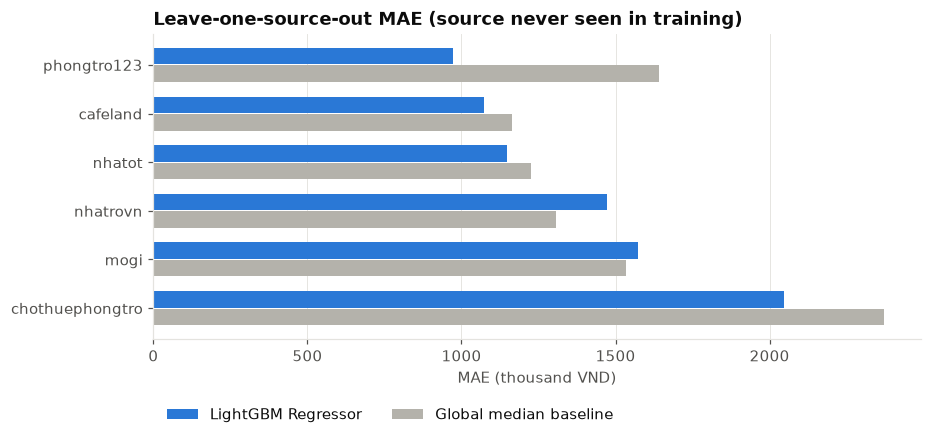

In [13]:
NO_SOURCE_FEATURES = [f for f in SELECTED_FEATURES if f != "source_code"]
ablation_rows = []
for label, features in [
    ("Without source_code", NO_SOURCE_FEATURES),
    ("With source_code", SELECTED_FEATURES),
]:
    ablation_rows += evaluate_config(LOCKED_MODEL, LOCKED_PARAMS, features, label, LOCKED_TRANSFORM)
source_ablation = summarize_development(pd.DataFrame(ablation_rows))
without = source_ablation.loc[source_ablation["Feature Set"].eq("Without source_code")].iloc[0]
with_source = source_ablation.loc[source_ablation["Feature Set"].eq("With source_code")].iloc[0]
SOURCE_ABLATION_ABSOLUTE = without.MAE_Mean - with_source.MAE_Mean
SOURCE_ABLATION_PERCENT = SOURCE_ABLATION_ABSOLUTE / with_source.MAE_Mean * 100
display(
    pd.Series(
        {
            "MAE with source_code": with_source.MAE_Mean,
            "MAE without source_code": without.MAE_Mean,
            "Degradation %": round(SOURCE_ABLATION_PERCENT, 2),
        },
        name="value",
    ).to_frame()
)

loso = []
for source in sorted(development_df.source_code.dropna().unique()):
    train = development_df.loc[development_df.source_code.ne(source)]
    score = development_df.loc[development_df.source_code.eq(source)]
    if len(score) < 100:
        continue
    if LOCKED_MODEL in BASELINES:
        pred = baseline_predict(LOCKED_MODEL, train, score)
    else:
        _, pred, _, _ = fit_predict(
            LOCKED_MODEL, LOCKED_PARAMS, SELECTED_FEATURES, train, score, LOCKED_TRANSFORM
        )
    base_mae = regression_metrics(score[TARGET], baseline_predict("Global Median", train, score))[
        "MAE"
    ]
    metrics = regression_metrics(score[TARGET], pred)
    loso.append(
        {
            "Held-out Source": source,
            "Rows": len(score),
            "Target Median": score[TARGET].median(),
            "Target P95": score[TARGET].quantile(0.95),
            "Target Max": score[TARGET].max(),
            **metrics,
            "Global Median MAE": base_mae,
            "Baseline Beats Locked": base_mae < metrics["MAE"],
        }
    )
leave_one_source_out = pd.DataFrame(loso).sort_values("MAE")

fig, ax = plt.subplots(figsize=(9, 3.6))
positions = np.arange(len(leave_one_source_out))
ax.barh(
    positions - 0.18,
    leave_one_source_out.MAE / 1e3,
    height=0.34,
    color=CATEGORICAL[0],
    label=f"{LOCKED_MODEL}",
)
ax.barh(
    positions + 0.18,
    leave_one_source_out["Global Median MAE"] / 1e3,
    height=0.34,
    color=NEUTRAL,
    label="Global median baseline",
)
ax.set_yticks(positions, leave_one_source_out["Held-out Source"])
ax.invert_yaxis()
ax.set(
    title="Leave-one-source-out MAE (source never seen in training)", xlabel="MAE (thousand VND)"
)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.18), ncol=2)
plt.show()

## 09. UNKNOWN sensitivity — PERMISSIVE vs STRICT (development only)

> **Why:** Show whether keeping UNKNOWN-intent rows (PERMISSIVE) changes conclusions versus STRICT.

In [14]:
def evaluate_sensitivity_population(policy):
    masks = build_modeling_eligibility(prepared, policy=policy)
    population = prepared.loc[masks.final_eligible].copy()
    population[TARGET] = population.price_model_value.astype(float)
    population["group_key"] = build_group_key(population)
    population["split"] = group_aware_split(population, population.group_key, seed=SEED).labels
    development = population.loc[population["split"].ne("TEST")].copy()
    population_folds = build_expanding_group_time_folds(
        development, development.group_key, n_splits=3
    )
    rows = []
    for fold in population_folds:
        fit = development.loc[fold.train_index]
        score = development.loc[fold.validation_index]
        for name, transform, params in [
            ("Hierarchical Segment Median", "RAW", {}),
            (LOCKED_MODEL, LOCKED_TRANSFORM, LOCKED_PARAMS),
        ]:
            if name == "Hierarchical Segment Median":
                pred = hierarchical_segment_median(fit, score)
            else:
                _, pred, _, _ = fit_predict(name, params, SELECTED_FEATURES, fit, score, transform)
            metrics = regression_metrics(score[TARGET], pred)
            squared = (score[TARGET].to_numpy(float) - pred) ** 2
            extreme = score[TARGET].to_numpy(float) > fit[TARGET].quantile(0.99)
            rows.append(
                {
                    "Policy": policy,
                    "Population Rows": len(population),
                    "Development Rows": len(development),
                    "Fold": fold.fold,
                    "Model": name,
                    "Target Transform": transform,
                    **metrics,
                    "Extreme Tail Squared Error %": (
                        float(squared[extreme].sum() / squared.sum() * 100)
                        if squared.sum()
                        else 0.0
                    ),
                }
            )
    stats = {
        "Policy": policy,
        "Population Rows": len(population),
        "Development Rows": len(development),
        "Target Median": population[TARGET].median(),
        "Target P95": population[TARGET].quantile(0.95),
        "Target P99": population[TARGET].quantile(0.99),
        "Area Median": population.area_value_clean.median(),
        "Area P95": population.area_value_clean.quantile(0.95),
        "Area P99": population.area_value_clean.quantile(0.99),
        "UNKNOWN Rows": int(population.listing_intent.eq("UNKNOWN").sum()),
    }
    return rows, stats


sensitivity_rows, sensitivity_populations, sensitivity_source_rows = [], [], []
for policy in ["PERMISSIVE", "STRICT"]:
    rows, stats = evaluate_sensitivity_population(policy)
    sensitivity_rows.extend(rows)
    sensitivity_populations.append(stats)
    subset = prepared.loc[build_modeling_eligibility(prepared, policy=policy).final_eligible]
    shares = subset.source_code.value_counts(normalize=True) * 100
    for source, count in subset.source_code.value_counts().items():
        sensitivity_source_rows.append(
            {
                "Policy": policy,
                "Source": source,
                "Rows": int(count),
                "Share %": round(float(shares[source]), 2),
            }
        )

unknown_sensitivity_sources = pd.DataFrame(sensitivity_source_rows)
unknown_sensitivity_fold_results = pd.DataFrame(sensitivity_rows)
unknown_sensitivity_summary = unknown_sensitivity_fold_results.groupby(
    ["Policy", "Population Rows", "Development Rows", "Model", "Target Transform"], as_index=False
).agg(
    Folds=("Fold", "nunique"),
    MAE=("MAE", "mean"),
    MAE_Std=("MAE", "std"),
    MedianAE=("Median AE", "mean"),
    RMSE=("RMSE", "mean"),
    RMSLE=("RMSLE", "mean"),
    R2=("R²", "mean"),
    Tail_Squared_Error_Pct=("Extreme Tail Squared Error %", "mean"),
)
baseline_mae = unknown_sensitivity_summary.loc[
    unknown_sensitivity_summary.Model.eq("Hierarchical Segment Median"), ["Policy", "MAE"]
].rename(columns={"MAE": "Baseline MAE"})
unknown_sensitivity_summary = unknown_sensitivity_summary.merge(
    baseline_mae, on="Policy", how="left"
)
unknown_sensitivity_summary["Baseline Improvement %"] = (
    (unknown_sensitivity_summary["Baseline MAE"] - unknown_sensitivity_summary.MAE)
    / unknown_sensitivity_summary["Baseline MAE"]
    * 100
)
unknown_sensitivity_population = pd.DataFrame(sensitivity_populations)
display(unknown_sensitivity_population)
display(
    unknown_sensitivity_summary[
        ["Policy", "Model", "Target Transform", "MAE", "MAE_Std", "R2", "Baseline Improvement %"]
    ]
)
assert not TEST_ACCESSED_FOR_SELECTION

,Policy,Population Rows,Development Rows,Target Median,Target P95,Target P99,Area Median,Area P95,Area P99,UNKNOWN Rows
0,PERMISSIVE,112281,95777,4000000.0,7000000.0,10000000.0,28.0,50.0,150.0,32947
1,STRICT,79334,67758,4000000.0,7200000.0,10000000.0,28.0,50.0,130.0,0


,Policy,Model,Target Transform,MAE,MAE_Std,R2,Baseline Improvement %
0,PERMISSIVE,Hierarchical Segment Median,RAW,961758.667185,43931.544984,0.212758,0.000000
1,PERMISSIVE,LightGBM Regressor,RAW,886970.382241,32577.851336,0.291672,7.776201
2,STRICT,Hierarchical Segment Median,RAW,946599.890279,37024.396466,0.246808,0.000000
3,STRICT,LightGBM Regressor,RAW,871375.097637,43852.562235,0.331508,7.946841


## 10. FINAL TEST — ONE-TIME EVALUATION

> **Why:** Retrain the immutable candidate on all development rows and evaluate it once on the sealed TEST; baselines use the identical TEST rows.

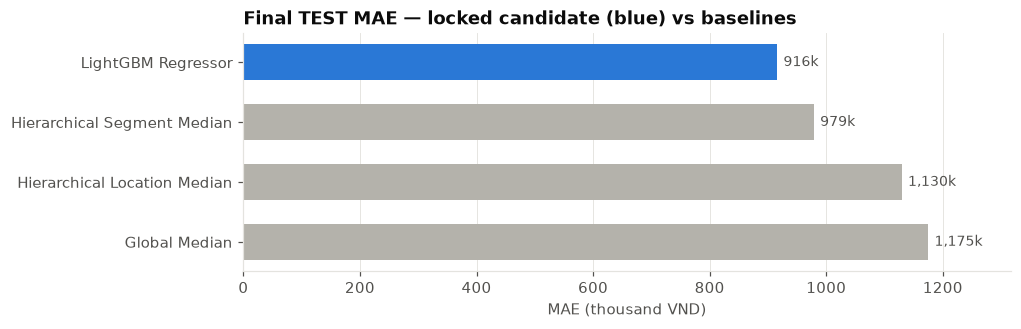

,Model,Target Transform,MAE,Median AE,RMSE,RMSLE,R²,Negative Predictions,Fit Time,Prediction Time
3,LightGBM Regressor,RAW,9.161272e+05,623718.266086,1.357988e+06,0.443944,0.205262,0,3.672762,0.034823
2,Hierarchical Segment Median,RAW,9.790948e+05,700000.000000,1.409180e+06,0.460907,0.144214,0,NaN,NaN
1,Hierarchical Location Median,RAW,1.129802e+06,900000.000000,1.527695e+06,0.500608,-0.005785,0,NaN,NaN
0,Global Median,RAW,1.175297e+06,1000000.000000,1.551384e+06,0.505561,-0.037219,0,NaN,NaN


In [15]:
assert LOCKED_MODEL and not TEST_ACCESSED_FOR_SELECTION
TEST_ACCESSED_FOR_SELECTION = True

test_predictions = pd.DataFrame(
    {
        "rental_post_id": test_df.rental_post_id.to_numpy(),
        "group_key": test_df.group_key.to_numpy(),
        "actual_price": test_df[TARGET].to_numpy(float),
        "source_code": test_df.source_code.to_numpy(),
        "ward_current": test_df.ward_current.to_numpy(),
        "district_text_extracted": test_df.district_text_extracted.to_numpy(),
        "province_text_extracted": test_df.province_text_extracted.to_numpy(),
        "area_value_clean": test_df.area_value_clean.to_numpy(),
        "ward_mapping_status": test_df.ward_mapping_status.to_numpy(),
        "parse_status": test_df.parse_status.to_numpy(),
        "title_clean": test_df.title_clean.to_numpy(),
        "latest_observed_at": test_df.latest_observed_at.to_numpy(),
    }
)
final_rows, final_model = [], None
for name in BASELINES:
    pred = baseline_predict(name, development_df, test_df)
    test_predictions[name] = pred
    final_rows.append(
        {"Model": name, "Target Transform": "RAW", **regression_metrics(test_df[TARGET], pred)}
    )
if LOCKED_MODEL in BASELINES:
    locked_pred = baseline_predict(LOCKED_MODEL, development_df, test_df)
else:
    final_model, locked_pred, fit_s, pred_s = fit_predict(
        LOCKED_MODEL, LOCKED_PARAMS, SELECTED_FEATURES, development_df, test_df, LOCKED_TRANSFORM
    )
    test_predictions[LOCKED_MODEL] = locked_pred
    final_rows.append(
        {
            "Model": LOCKED_MODEL,
            "Target Transform": LOCKED_TRANSFORM,
            **regression_metrics(test_df[TARGET], locked_pred),
            "Fit Time": fit_s,
            "Prediction Time": pred_s,
        }
    )
final_test = pd.DataFrame(final_rows).drop_duplicates("Model").sort_values("MAE")
assert len(test_predictions) == len(test_df) == test_predictions.rental_post_id.nunique()

colors = [CATEGORICAL[0] if model == LOCKED_MODEL else NEUTRAL for model in final_test.Model]
fig, ax = plt.subplots(figsize=(9, 2.8))
bars = ax.barh(final_test.Model, final_test.MAE / 1e3, color=colors, height=0.6)
ax.bar_label(
    bars,
    labels=[f"{v / 1e3:,.0f}k" for v in final_test.MAE],
    padding=4,
    fontsize=9,
    color="#52514e",
)
ax.invert_yaxis()
ax.set(title="Final TEST MAE — locked candidate (blue) vs baselines", xlabel="MAE (thousand VND)")
ax.margins(x=0.12)
plt.show()
display(final_test)

## 11. Tail, segment, prediction-sanity and largest-error diagnostics

> **Why:** Find where errors come from: the price tail, segments, implausible predictions and the worst rows.

In [16]:
baseline_name = "Hierarchical Segment Median"
names = list(dict.fromkeys([baseline_name, LOCKED_MODEL]))
dev_p95, dev_p99 = development_df[TARGET].quantile(0.95), development_df[TARGET].quantile(0.99)
diagnostics = []
for name in names:
    pred = test_predictions[name]
    actual = test_predictions.actual_price
    ae, se = (actual - pred).abs(), (actual - pred) ** 2
    regions = [("Central ≤ dev P95", actual <= dev_p95)]
    if dev_p99 > dev_p95:
        regions.append(("Upper P95–P99", (actual > dev_p95) & (actual <= dev_p99)))
    regions.append(("Extreme > dev P99", actual > dev_p99))
    for region, mask in regions:
        diagnostics.append(
            {
                "Model": name,
                "Region": region,
                "Count": int(mask.sum()),
                "MAE": ae[mask].mean(),
                "RMSE": np.sqrt(se[mask].mean()),
                "Squared Error Contribution %": se[mask].sum() / se.sum() * 100,
            }
        )
tail_diagnostics = pd.DataFrame(diagnostics)
display(tail_diagnostics)

price_band, price_edges = unique_price_bands(development_df[TARGET], test_predictions.actual_price)
_, _, area_edges = add_train_only_area_band(development_df, test_df)
area_band = pd.cut(test_predictions.area_value_clean, area_edges, include_lowest=True)
location_resolution = np.where(
    test_predictions.ward_current.notna(),
    "WARD_RESOLVED",
    np.where(test_predictions.district_text_extracted.notna(), "DISTRICT_ONLY", "UNRESOLVED"),
)
segments = []
for dimension, values in {
    "Price Band": price_band,
    "Source": test_predictions.source_code,
    "Area Band": area_band,
    "Location Resolution": location_resolution,
}.items():
    for segment, idx in (
        pd.Series(values, index=test_predictions.index)
        .groupby(values, dropna=False, observed=False)
        .groups.items()
    ):
        base = (
            (test_predictions.loc[idx, "actual_price"] - test_predictions.loc[idx, baseline_name])
            .abs()
            .mean()
        )
        locked = (
            (test_predictions.loc[idx, "actual_price"] - test_predictions.loc[idx, LOCKED_MODEL])
            .abs()
            .mean()
        )
        segments.append(
            {
                "Dimension": dimension,
                "Segment": str(segment),
                "Count": len(idx),
                "Small Sample (<100)": len(idx) < 100,
                "Baseline MAE": base,
                "Locked MAE": locked,
                "Baseline Beats Locked": base < locked,
            }
        )
segment_diagnostics = pd.DataFrame(segments)
display(segment_diagnostics.sort_values(["Dimension", "Locked MAE"]))

,Model,Region,Count,MAE,RMSE,Squared Error Contribution %
0,Hierarchical Segment Median,Central ≤ dev P95,16258,9.286419e+05,1.268218e+06,79.787045
1,Hierarchical Segment Median,Upper P95–P99,217,3.623825e+06,3.837078e+06,9.748521
2,Hierarchical Segment Median,Extreme > dev P99,29,9.474138e+06,1.087477e+07,10.464434
3,LightGBM Regressor,Central ≤ dev P95,16258,8.658730e+05,1.210128e+06,78.225581
4,LightGBM Regressor,Upper P95–P99,217,3.502921e+06,3.725537e+06,9.895925
5,LightGBM Regressor,Extreme > dev P99,29,9.733296e+06,1.116535e+07,11.878494


,Dimension,Segment,Count,Small Sample (<100),Baseline MAE,Locked MAE,Baseline Beats Locked
11,Area Band,"(-inf, 20.0]",5123,False,8.058386e+05,7.079895e+05,False
13,Area Band,"(25.0, 28.0]",939,False,7.665282e+05,7.165775e+05,False
12,Area Band,"(20.0, 25.0]",4286,False,8.303402e+05,8.072193e+05,False
14,Area Band,"(28.0, 30.0]",2944,False,9.935258e+05,9.661590e+05,False
15,Area Band,"(30.0, 35.0]",1381,False,1.205264e+06,1.149059e+06,False
16,Area Band,"(35.0, inf]",1831,False,1.727281e+06,1.599619e+06,False
17,Location Resolution,DISTRICT_ONLY,2203,False,1.025279e+06,8.878017e+05,False
19,Location Resolution,WARD_RESOLVED,11895,False,9.502640e+05,8.948848e+05,False
18,Location Resolution,UNRESOLVED,2406,False,1.079343e+06,1.047083e+06,False
1,Price Band,Band 2,3400,False,7.302000e+05,6.605076e+05,False


,Model,Pred Min,Pred Median,Pred P95,Pred P99,Pred Max,Actual Min,Actual Max,Negative,Zero,Outside 100k–100m
0,Hierarchical Segment Median,750000.000000,3.600000e+06,5.150000e+06,5.800000e+06,1.000000e+07,250000.0,35000000.0,0,0,0
1,LightGBM Regressor,777030.622127,3.771708e+06,5.316183e+06,5.724857e+06,6.829048e+06,250000.0,35000000.0,0,0,0


,rental_post_id,actual_price,predicted_price,absolute_error,source_code,area_value_clean,ward_current,title_clean
7345,114400,35000000.0,3.557111e+06,3.144289e+07,phongtro123,40.0,NaN,"CHO THUE NHA CAP 4 GAN DAI HOC NGAN HANG, CAO ..."
295,77546,30000000.0,4.499207e+06,2.550079e+07,cafeland,100.0,Phường Bình Lợi Trung,Phòng trọ: CHO THUÊ NHÀ ( 5x20m) 30triệu Đường...
13912,228615,15000000.0,3.086546e+06,1.191345e+07,phongtro123,100.0,Phường Xóm Chiếu,Cho thuê nguyên tầng 1 ( có 3 phòng ) mặt tiền...
344,77599,18000000.0,6.233976e+06,1.176602e+07,cafeland,60.0,Phường Bình Lợi Trung,Phòng trọ: CHO THUÊ NHÀ (4x15m) giá 18 triệu Đ...
15276,234178,15000000.0,3.675966e+06,1.132403e+07,phongtro123,60.0,NaN,"Cho thuê nhà lầu 2,3 + sân thượng 0931151510 T..."
13907,228610,14000000.0,3.609006e+06,1.039099e+07,phongtro123,88.0,Phường Phú Thọ Hòa,Căn hộ full nội thất Quận Tân Phú 88m² 2PN
6031,110216,12500000.0,2.650433e+06,9.849567e+06,phongtro123,1000.0,NaN,2PN TRUNG TÂM QUẬN BT(trống sẵn)
11063,221172,13000000.0,3.304492e+06,9.695508e+06,phongtro123,48.0,Phường Phú Định,Nhà cho thuê hẻm An Dương Vương quận 8 gần chu...
11712,222399,12000000.0,2.499085e+06,9.500915e+06,phongtro123,100.0,NaN,"Penthouse Q.Tân Bình, Phạm Văn Bạch, 1 bếp, 3 ..."
11767,224133,12000000.0,2.499085e+06,9.500915e+06,phongtro123,100.0,NaN,"PENTHOUSE VIP Q TÂN BÌNH, PHẠM VĂN BẠCH GỒM 3 ..."


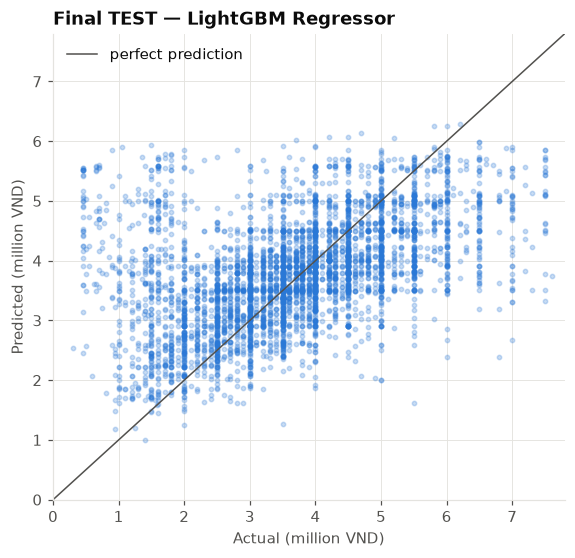

In [17]:
plausible_min, plausible_max = 100_000, 100_000_000
sanity = pd.DataFrame(
    [
        {
            "Model": n,
            "Pred Min": test_predictions[n].min(),
            "Pred Median": test_predictions[n].median(),
            "Pred P95": test_predictions[n].quantile(0.95),
            "Pred P99": test_predictions[n].quantile(0.99),
            "Pred Max": test_predictions[n].max(),
            "Actual Min": test_predictions.actual_price.min(),
            "Actual Max": test_predictions.actual_price.max(),
            "Negative": int((test_predictions[n] < 0).sum()),
            "Zero": int((test_predictions[n] == 0).sum()),
            "Outside 100k–100m": int(
                (
                    (test_predictions[n] < plausible_min) | (test_predictions[n] > plausible_max)
                ).sum()
            ),
        }
        for n in names
    ]
)
display(sanity)

largest = test_predictions.assign(
    predicted_price=test_predictions[LOCKED_MODEL],
    absolute_error=(test_predictions.actual_price - test_predictions[LOCKED_MODEL]).abs(),
).nlargest(25, "absolute_error")
display(
    largest[
        [
            "rental_post_id",
            "actual_price",
            "predicted_price",
            "absolute_error",
            "source_code",
            "area_value_clean",
            "ward_current",
            "title_clean",
        ]
    ].head(10)
)

sample = test_predictions.sample(min(5000, len(test_predictions)), random_state=SEED)
limit = test_predictions.actual_price.quantile(0.99) / 1e6
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(
    sample.actual_price / 1e6, sample[LOCKED_MODEL] / 1e6, s=8, alpha=0.25, color=CATEGORICAL[0]
)
ax.plot([0, limit], [0, limit], color="#52514e", linewidth=1, label="perfect prediction")
ax.set(
    xlim=(0, limit),
    ylim=(0, limit),
    xlabel="Actual (million VND)",
    ylabel="Predicted (million VND)",
    title=f"Final TEST — {LOCKED_MODEL}",
)
ax.grid(axis="y")
ax.legend(loc="upper left")
plt.show()

## 12. Locked-model feature importance and final verdict

> **Why:** Explain what the locked model uses and state an honest readiness verdict.

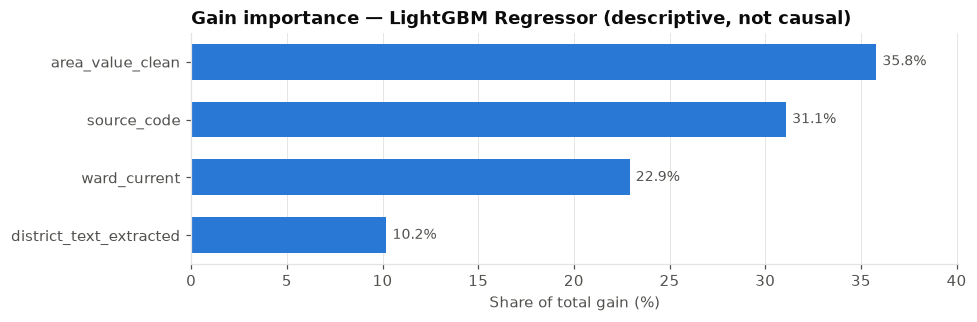

,Criterion,Current runtime result
0,Locked candidate,LightGBM Regressor
1,Target transform,RAW
2,Feature set,F4 — AREA + SOURCE + LOCATION
3,TEST MAE,916127.200191
4,TEST MedianAE,623718.266086
5,TEST RMSE,1357988.108061
6,TEST RMSLE,0.443944
7,TEST R²,0.205262
8,Improvement vs Global Median %,22.051424
9,Improvement vs Location Median %,18.912622


In [18]:
if LOCKED_MODEL == "LightGBM Regressor":
    feature_importance = lightgbm_gain_importance(final_model, SELECTED_FEATURES)
else:
    feature_importance = pd.DataFrame(
        {"Feature": SELECTED_FEATURES, "Gain": np.nan, "Split Count": np.nan, "Gain %": np.nan}
    )
if feature_importance.Gain.notna().any():
    bar_chart(
        feature_importance.set_index("Feature")["Gain %"],
        title=f"Gain importance — {LOCKED_MODEL} (descriptive, not causal)",
        xlabel="Share of total gain (%)",
        fmt="{:.1f}%",
    )
    plt.show()

final_locked = final_test.loc[final_test.Model.eq(LOCKED_MODEL)].iloc[0]
baseline_metrics = {name: final_test.loc[final_test.Model.eq(name)].iloc[0] for name in BASELINES}
locked_dev = (
    candidate_pool.loc[
        candidate_pool.Model.eq(LOCKED_MODEL)
        & candidate_pool.Parameters.eq(json.dumps(LOCKED_PARAMS, sort_keys=True))
    ]
    .sort_values("MAE_Mean")
    .iloc[0]
)
tail_locked = tail_diagnostics.loc[tail_diagnostics.Model.eq(LOCKED_MODEL)]
extreme = tail_locked.loc[tail_locked.Region.str.startswith("Extreme")].iloc[0]
central = tail_locked.loc[tail_locked.Region.str.startswith("Central")].iloc[0]
short_window = (model_df.latest_observed_at.max() - model_df.latest_observed_at.min()).days < 30
unstable = locked_dev.MAE_Std / locked_dev.MAE_Mean > 0.15
readiness = (
    "experimental/prototype-ready; not production-ready"
    if unstable or short_window or extreme["Squared Error Contribution %"] > 50
    else "production-candidate pending operational validation"
)


def improvement(name):
    return (baseline_metrics[name].MAE - final_locked.MAE) / baseline_metrics[name].MAE * 100


verdict = pd.DataFrame(
    [
        ["Locked candidate", LOCKED_MODEL],
        ["Target transform", LOCKED_TRANSFORM],
        ["Feature set", SELECTED_FEATURE_SET],
        ["TEST MAE", final_locked.MAE],
        ["TEST MedianAE", final_locked["Median AE"]],
        ["TEST RMSE", final_locked.RMSE],
        ["TEST RMSLE", final_locked.RMSLE],
        ["TEST R²", final_locked["R²"]],
        ["Improvement vs Global Median %", improvement("Global Median")],
        ["Improvement vs Location Median %", improvement("Hierarchical Location Median")],
        ["Improvement vs Strong Segment Median %", improvement("Hierarchical Segment Median")],
        ["Development MAE mean", locked_dev.MAE_Mean],
        ["Development MAE median", locked_dev.MAE_Median],
        ["Development MAE std", locked_dev.MAE_Std],
        ["Source ablation degradation %", SOURCE_ABLATION_PERCENT],
        ["Extreme-tail squared error share %", extreme["Squared Error Contribution %"]],
        ["Central-population MAE", central.MAE],
        ["Readiness", readiness],
        ["Limitation", "short-horizon temporal evidence only"],
    ],
    columns=["Criterion", "Current runtime result"],
)
display(verdict)

## 13. Consistency with the locked champion (read-only)

> **Why:** This run re-executes selection on the current Silver. The locked champion must not be re-selected, so compare this run's choice with the persisted champion and report any difference.

In [19]:
ARTIFACT_DIR = PROJECT_ROOT / "data" / "modeling" / "roombeacon_price_benchmark_v3"
locked_champion = json.loads((ARTIFACT_DIR / "champion_metadata.json").read_text(encoding="utf-8"))
consistency = pd.DataFrame(
    [
        ["Model family", locked_champion["model_family"], LOCKED_MODEL],
        ["Target transform", locked_champion["target_transform"], LOCKED_TRANSFORM],
        ["Feature set", locked_champion["feature_set"], SELECTED_FEATURE_SET],
        [
            "Hyperparameters",
            json.dumps(locked_champion["hyperparameters"], sort_keys=True),
            json.dumps(LOCKED_PARAMS, sort_keys=True),
        ],
    ],
    columns=["Item", "Locked champion", "This run"],
)
consistency["Match"] = consistency["Locked champion"].eq(consistency["This run"])
display(consistency)
CHAMPION_REPRODUCED = bool(consistency.Match.all())
display(
    Markdown(
        f"**Locked champion `{locked_champion['model_id']}` reproduced by this run.**"
        if CHAMPION_REPRODUCED
        else f"**This run would choose a different configuration than the locked champion `{locked_champion['model_id']}`.** "
        "The champion stays locked; a change requires an explicit re-selection decision, not a notebook re-run."
    )
)

,Item,Locked champion,This run,Match
0,Model family,LightGBM Regressor,LightGBM Regressor,True
1,Target transform,RAW,RAW,True
2,Feature set,F4 — AREA + SOURCE + LOCATION,F4 — AREA + SOURCE + LOCATION,True
3,Hyperparameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3...","{""learning_rate"": 0.05, ""min_child_samples"": 3...",True


**Locked champion `roombeacon-price-lgbm-f4-raw-0b0c9d9fa450` reproduced by this run.**

## 14. Persist auditable benchmark evidence

> **Why:** Write the benchmark tables and champion artifact. **Tagged `skip-execution`** so a normal run (and the published outputs) never overwrite the locked champion; run it manually only for an approved re-selection.

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
tables = {
    "eligibility_funnel_permissive.csv": eligibility_funnel_permissive,
    "eligibility_funnel_strict.csv": eligibility_funnel_strict,
    "semantic_population_summary.csv": semantic_population_summary,
    "semantic_exclusion_summary.csv": semantic_exclusion_summary,
    "semantic_exclusion_examples.csv": semantic_exclusion_examples,
    "target_distribution_comparison.csv": target_distribution_comparison,
    "valid_high_price_examples.csv": valid_high_price_examples,
    "development_fold_results.csv": development_fold_results,
    "development_comparison.csv": development_comparison,
    "feature_fold_results.csv": feature_fold_results,
    "feature_summary.csv": feature_summary,
    "f4_f5_decision.csv": f45_decision,
    "tuning_fold_results.csv": tuning_fold_results,
    "tuning_summary.csv": tuning_summary,
    "source_ablation.csv": source_ablation,
    "leave_one_source_out.csv": leave_one_source_out,
    "unknown_sensitivity_population.csv": unknown_sensitivity_population,
    "unknown_sensitivity_sources.csv": unknown_sensitivity_sources,
    "unknown_sensitivity_fold_results.csv": unknown_sensitivity_fold_results,
    "unknown_sensitivity_summary.csv": unknown_sensitivity_summary,
    "final_test.csv": final_test,
    "tail_diagnostics.csv": tail_diagnostics,
    "segment_diagnostics.csv": segment_diagnostics,
    "prediction_sanity.csv": sanity,
    "feature_importance.csv": feature_importance,
    "final_verdict.csv": verdict,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
with duckdb.connect(":memory:") as con:
    con.register("_pred", test_predictions)
    con.execute(
        "COPY _pred TO ? (FORMAT PARQUET)", [str(ARTIFACT_DIR / "test_predictions.parquet")]
    )

generated_at = datetime.now(timezone.utc).astimezone().isoformat()
metadata = {
    "benchmark": "roombeacon_price_benchmark_v3",
    "generated_at": generated_at,
    "versions": versions,
    "hardware": {
        "platform": platform.platform(),
        "processor": platform.processor(),
        "cpu_count": os.cpu_count(),
    },
    "seed": SEED,
    "silver_path": str(SILVER_PATH),
    "silver_sha256": file_sha256(SILVER_PATH),
    "silver_metadata": silver_metadata,
    "business_target_definition": BUSINESS_TARGET_DEFINITION,
    "semantic_eligibility_policy": "PERMISSIVE default keeps unresolved UNKNOWN absent strong conflict; STRICT is development-only sensitivity evidence",
    "numeric_trust_policy": sorted(TRUSTED_PRICE_STATUSES),
    "price_model_suitability_policy": ["SUPPORTED"],
    "area_model_suitability_policy": ["SUPPORTED"],
    "eligible_rows": len(model_df),
    "numeric_untrusted_rows": int((numeric_candidate & ~numeric_trusted).sum()),
    "intent_distribution": prepared.listing_intent.value_counts(dropna=False).to_dict(),
    "scope_distribution": prepared.rental_scope.value_counts(dropna=False).to_dict(),
    "trust_distribution": prepared.price_target_trust_status.value_counts(dropna=False).to_dict(),
    "price_suitability_distribution": prepared.price_model_suitability.value_counts(
        dropna=False
    ).to_dict(),
    "area_suitability_distribution": prepared.area_model_suitability.value_counts(
        dropna=False
    ).to_dict(),
    "split_strategy": split_result.strategy,
    "folds": fold_report.astype(str).to_dict("records"),
    "selected_feature_set": SELECTED_FEATURE_SET,
    "feature_names": SELECTED_FEATURES,
    "locked_candidate": LOCKED_MODEL,
    "locked_transform": LOCKED_TRANSFORM,
    "locked_parameters": LOCKED_PARAMS,
    "categorical_strategy": "LightGBM train-defined pandas categories with explicit __MISSING__/__UNKNOWN__; CatBoost native strings; sklearn fold-fitted unknown-safe encoders",
    "selection_rule": "Development fold MAE mean/median/variability; within 1% prefer lower complexity; then MedianAE/RMSLE/runtime",
    "historical_test_previously_observed": True,
    "test_used_for_current_selection": False,
    "readiness": readiness,
    "limitations": [
        "short temporal window",
        "historical temporal test range has already been observed",
        "group-level chronology uses representative max timestamp",
        "source mix is dataset representation, not market share",
    ],
}
assert (
    LOCKED_MODEL == "LightGBM Regressor"
    and LOCKED_TRANSFORM == "RAW"
    and SELECTED_FEATURE_SET == F4
)
champion_cats = [c for c in SELECTED_FEATURES if c in CATS]
reference_matrix, _, champion_vocabularies = prepare_lightgbm_categories(
    development_df[SELECTED_FEATURES],
    development_df[SELECTED_FEATURES],
    champion_cats,
    return_vocabularies=True,
)
reference_predictions = inverse_target(final_model.predict(reference_matrix), LOCKED_TRANSFORM)
reference_profile = build_reference_profile(
    development_df,
    reference_predictions,
    target_column=TARGET,
    population_name="DEVELOPMENT",
    uses_test=False,
)
training_reference = {
    "population": "DEVELOPMENT",
    "row_count": len(development_df),
    "group_count": development_df.group_key.nunique(),
    "min_observed_at": development_df.latest_observed_at.min().isoformat(),
    "max_observed_at": development_df.latest_observed_at.max().isoformat(),
    "training_cutoff": development_df.latest_observed_at.max().isoformat(),
    "evidence_cutoff": silver_df.latest_observed_at.max().isoformat(),
    "uses_test": False,
    "silver_sha256": metadata["silver_sha256"],
    "source_snapshot_id": silver_metadata.get("source_snapshot", {}).get("snapshot_id"),
}
champion_metadata = persist_champion_artifact(
    final_model,
    ARTIFACT_DIR,
    model_family=LOCKED_MODEL,
    target_transform=LOCKED_TRANSFORM,
    feature_set=SELECTED_FEATURE_SET,
    feature_names=SELECTED_FEATURES,
    hyperparameters=LOCKED_PARAMS,
    random_seed=SEED,
    categorical_vocabularies=champion_vocabularies,
    training_reference=training_reference,
    expected_schema={
        "area_value_clean": "numeric",
        "source_code": "categorical",
        "ward_current": "categorical",
        "district_text_extracted": "categorical",
    },
    reference_profile=reference_profile,
    created_at=generated_at,
)
metadata["training_reference"] = training_reference
metadata["model_version"] = champion_metadata["model_id"]
metadata["champion"] = {
    "model_id": champion_metadata["model_id"],
    "artifact_path": champion_metadata["artifact_path"],
    "metadata_path": "champion_metadata.json",
    "reference_profile_path": "champion_reference_profile.json",
    "artifact_sha256": champion_metadata["artifact_sha256"],
}
(ARTIFACT_DIR / "experiment_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8"
)
display(
    pd.DataFrame(
        [{"Artifact": p.name, "Bytes": p.stat().st_size} for p in sorted(ARTIFACT_DIR.iterdir())]
    )
)

## Summary

In [20]:
best_baseline = final_test.loc[final_test.Model.isin(BASELINES)].iloc[0]
display(
    Markdown(
        f"""
**Key findings**

- **{len(model_df):,}** of {len(silver_df):,} Silver listings ({len(model_df) / len(silver_df):.0%}) are eligible model targets.
- Feature decision: **{SELECTED_FEATURE_SET}** (F5 improvement {aggregate_gain:.2f}% {"≥" if aggregate_gain >= 1 else "<"} 1% threshold).
- Candidate locked before TEST: **{LOCKED_MODEL} / {LOCKED_TRANSFORM}**.
- Final TEST: MAE **{final_locked.MAE:,.0f} VND**, R² **{final_locked["R²"]:.2f}**; best baseline ({best_baseline.Model}) MAE {best_baseline.MAE:,.0f} VND
  ({improvement(best_baseline.Model):+.1f}%).
- Removing `source_code` changes development MAE by {SOURCE_ABLATION_PERCENT:+.1f}%; extreme prices (> dev P99) carry
  {extreme["Squared Error Contribution %"]:.0f}% of squared error.
- Verdict: **{readiness}**. Locked champion reproduced by this run: **{"yes" if CHAMPION_REPRODUCED else "no — see section 13"}**.

**Next step:** Notebook 06 validates the locked champion on new data; Notebook 07 measures its runtime performance.
"""
    )
)


**Key findings**

- **112,281** of 132,494 Silver listings (85%) are eligible model targets.
- Feature decision: **F4 — AREA + SOURCE + LOCATION** (F5 improvement 0.82% < 1% threshold).
- Candidate locked before TEST: **LightGBM Regressor / RAW**.
- Final TEST: MAE **916,127 VND**, R² **0.21**; best baseline (Hierarchical Segment Median) MAE 979,095 VND
  (+6.4%).
- Removing `source_code` changes development MAE by +6.7%; extreme prices (> dev P99) carry
  12% of squared error.
- Verdict: **experimental/prototype-ready; not production-ready**. Locked champion reproduced by this run: **yes**.

**Next step:** Notebook 06 validates the locked champion on new data; Notebook 07 measures its runtime performance.
